<a href="https://colab.research.google.com/github/kazukichi0914/pe-network/blob/main/PE%E3%83%8D%E3%83%83%E3%83%88%E3%83%AF%E3%83%BC%E3%82%AF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# 日本語フォントをインストール
!pip install japanize-matplotlib
import japanize_matplotlib

  Using cached japanize-matplotlib-1.1.3.tar.gz (4.1 MB)
  Preparing metadata (setup.py) ... done
  Created wheel for japanize-matplotlib: filename=japanize_matplotlib-1.1.3-py3-none-any.whl size=4120257 sha256=721f62c8f3f2f60cc0f0e14ae572a53c3c032ead66bac58d644555cb95fd96aa
  Stored in directory: /root/.cache/pip/wheels/c1/f7/9b/418f19a7b9340fc16e071e89efc379aca68d40238b258df53d
Successfully built japanize-matplotlib


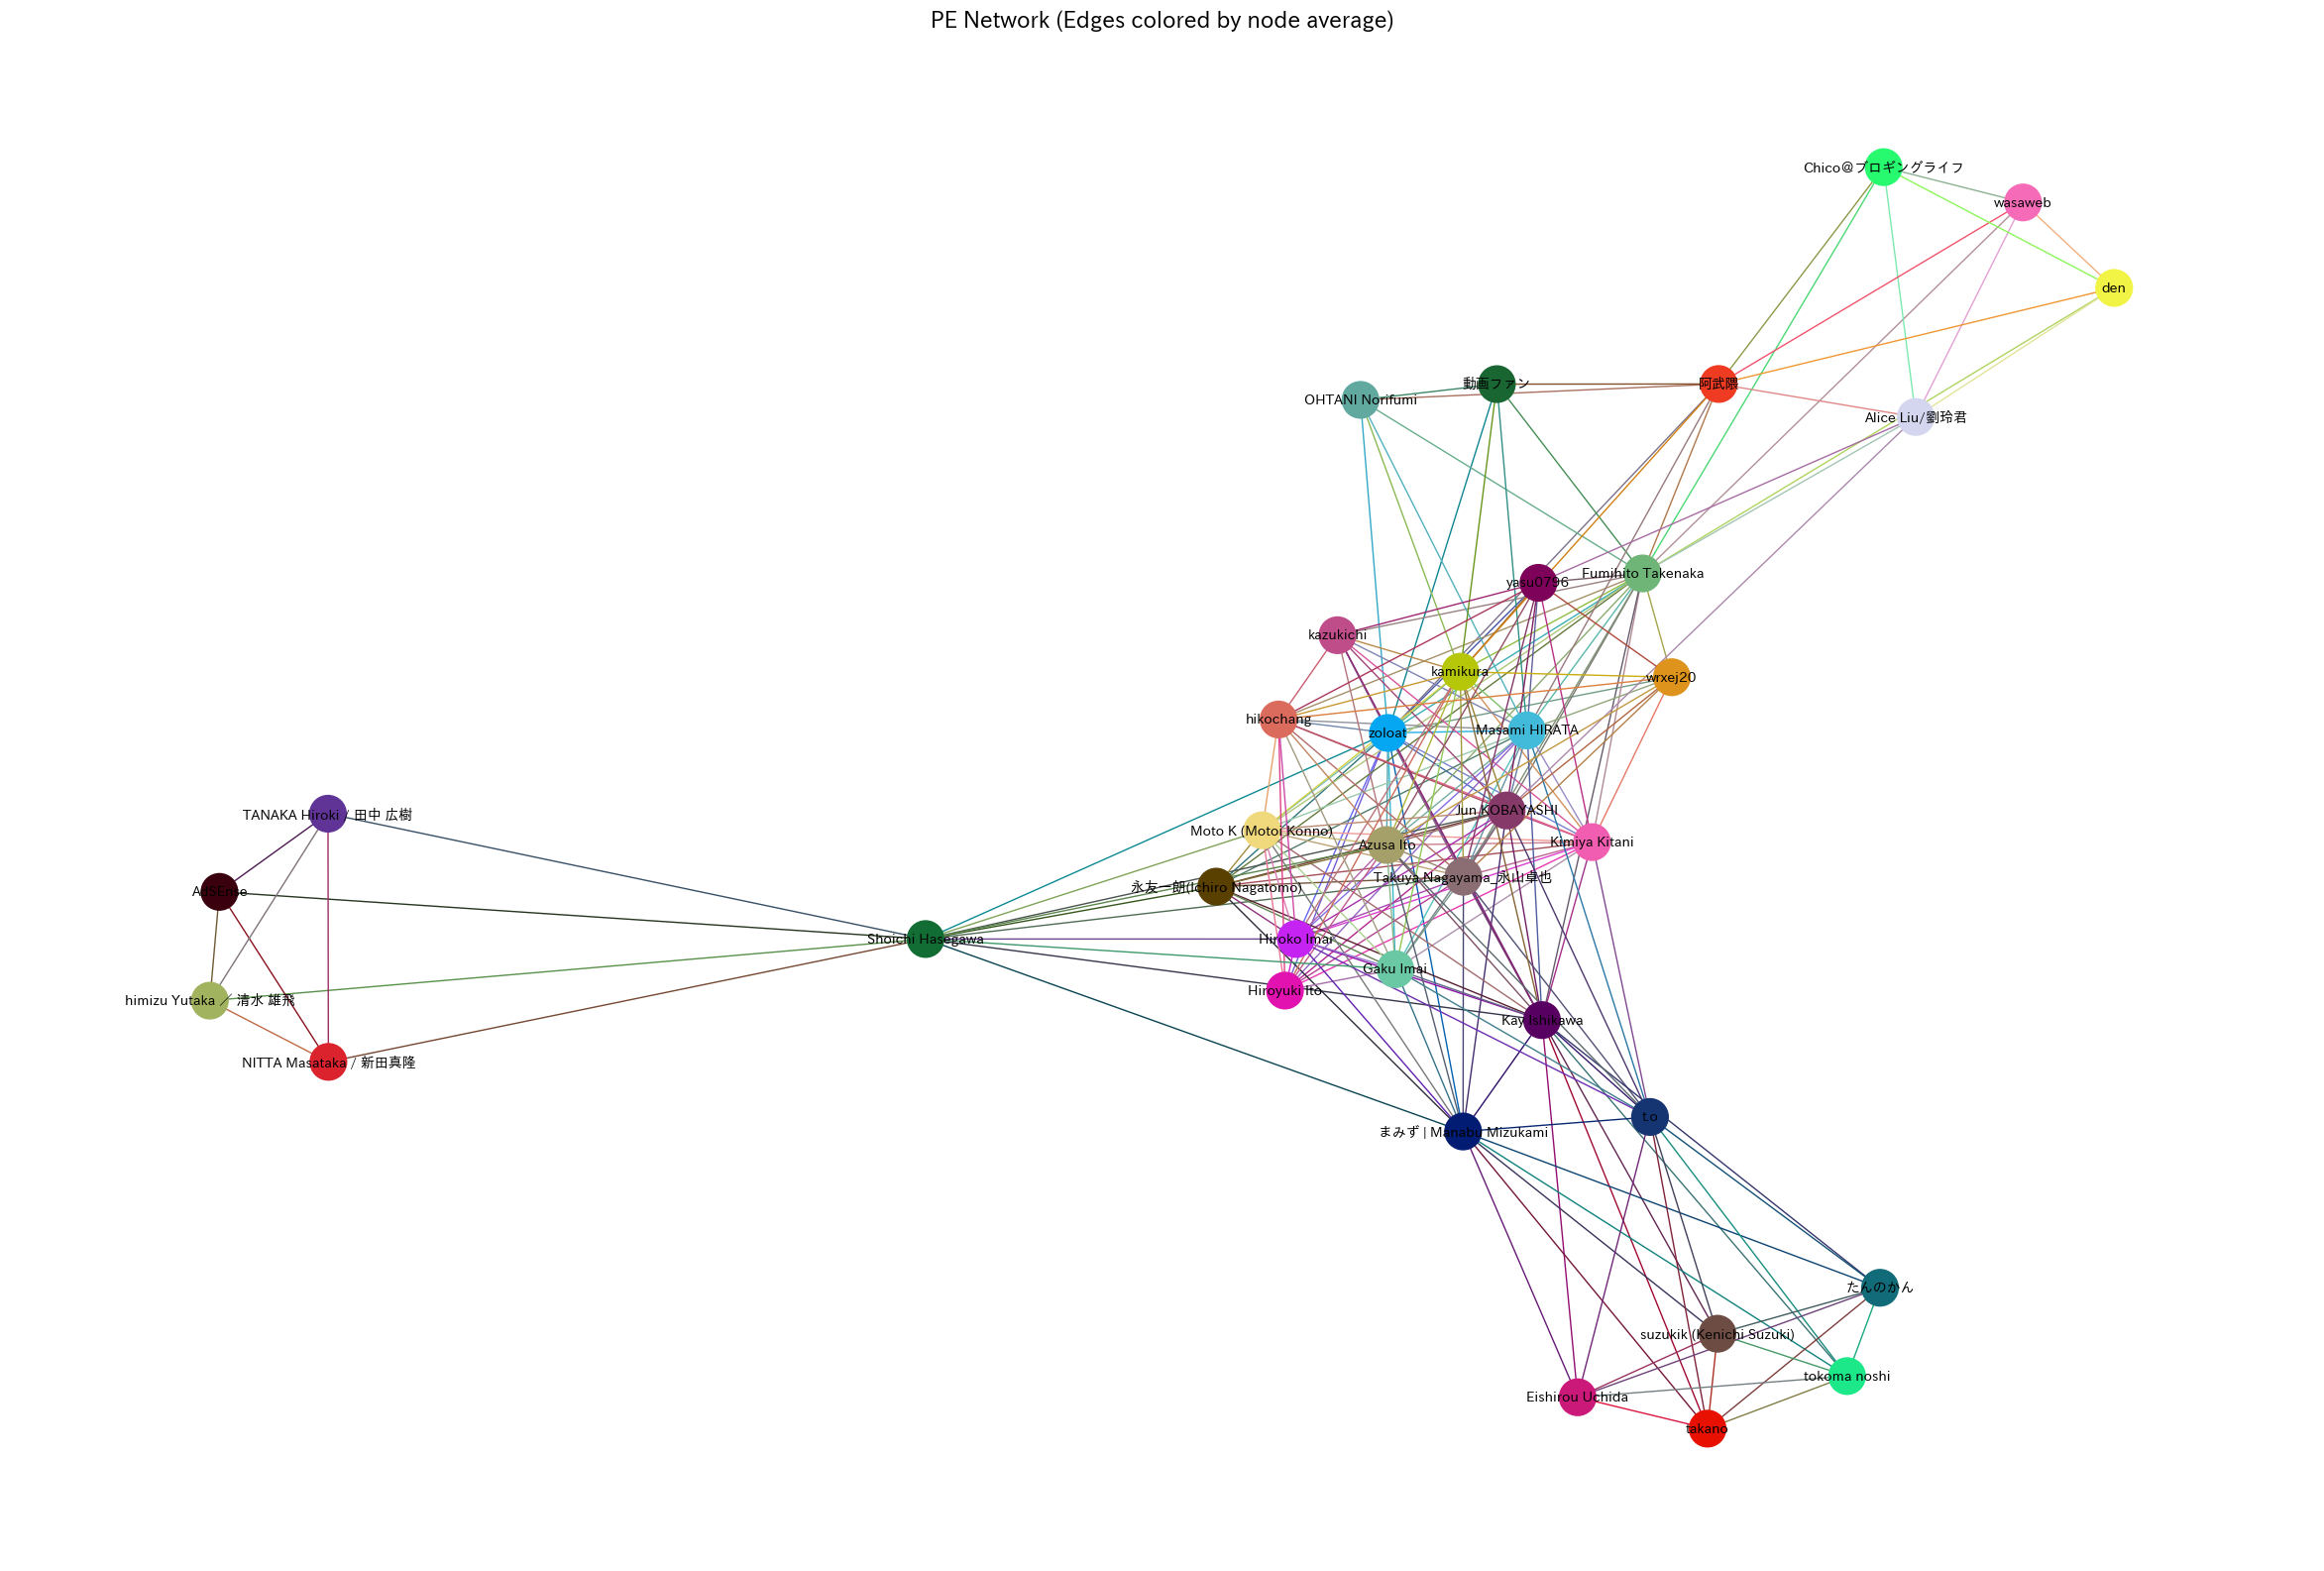

In [ ]:
import matplotlib.pyplot as plt
import networkx as nx
import random
import matplotlib.colors as mcolors

# 日本語フォントをインストール
!pip install japanize-matplotlib
import japanize_matplotlib

# 与えられた組み合わせ（施設のグループ）
combinations = [
    #Android
    ["zoloat", "Fumihito Takenaka","Kimiya Kitani","Masami HIRATA","Jun KOBAYASHI"],
    #Gboard
    ["yasu0796"],
    #Gemini
    ["Takuya Nagayama_永山卓也","Kay Ishikawa","永友一朗(Ichiro Nagatomo)","Moto K (Motoi Konno)","Fumihito Takenaka","Kimiya Kitani","Masami HIRATA","Jun KOBAYASHI"],
    #Gmail
    ["kamikura","zoloat","Azusa Ito","Kimiya Kitani","yasu0796","Masami HIRATA","Jun KOBAYASHI"],
    #AdManager
    ["Alice Liu/劉玲君"],
    #Admob
    ["Alice Liu/劉玲君","yasu0796","Jun KOBAYASHI"],
    #AdSense
    ["阿武隈","den","wasaweb","Alice Liu/劉玲君","Chico＠ブロギングライフ"],
    #Chrome
    ["kamikura","zoloat","wrxej20"],
    #Google Pixel
    ["kamikura","hikochang","Takuya Nagayama_永山卓也","zoloat","wrxej20","Azusa Ito","Fumihito Takenaka","Kimiya Kitani","yasu0796","Masami HIRATA","Jun KOBAYASHI"],
    #Google Pixel   Buds
    ["Alice Liu/劉玲君"],
    #AdSense
    ["阿武隈","den","wasaweb","Alice Liu/劉玲君","Chico＠ブロギングライフ","Fumihito Takenaka"],
    #Chrome
    ["kamikura","zoloat","wrxej20","Azusa Ito","Kimiya Kitani","yasu0796","Masami HIRATA","Jun KOBAYASHI"],
    #Google Pixel
    ["kamikura","hikochang","Takuya Nagayama_永山卓也","zoloat","wrxej20","Azusa Ito","Fumihito Takenaka","Kimiya Kitani","yasu0796","Masami HIRATA","Jun KOBAYASHI"],
    #Google Pixel   Buds
    ["Jun KOBAYASHI"],
    #アカウント
    ["kamikura","hikochang","Hiroyuki Ito","zoloat","Azusa Ito","Kimiya Kitani","Masami HIRATA"],
    #アシスタント
    ["Azusa Ito","Kimiya Kitani","Masami HIRATA","Jun KOBAYASHI"],
    #グループ
    ["Takuya Nagayama_永山卓也","Kimiya Kitani","Masami HIRATA","Jun KOBAYASHI"],
    #ビジネスプロフィール
    ["Hiroko Imai","Takuya Nagayama_永山卓也","zoloat","Kay Ishikawa","Shoichi Hasegawa","まみず | Manabu Mizukami","永友一朗(Ichiro Nagatomo)","Moto K (Motoi Konno)","Gaku Imai","Azusa Ito","Jun KOBAYASHI"],
    #マップ
    ["kamikura","Hiroko Imai","hikochang","Hiroyuki Ito","Takuya Nagayama_永山卓也","zoloat","Moto K (Motoi Konno)","Gaku Imai","Azusa Ito","Kimiya Kitani","Masami HIRATA","Jun KOBAYASHI"],
    #検索
    ["Hiroko Imai","Takuya Nagayama_永山卓也","Kay Ishikawa","t.o","Gaku Imai","Azusa Ito","Kimiya Kitani","Masami HIRATA","Jun KOBAYASHI"],
    #検索セントラル
    ["Kay Ishikawa","takano","tokoma noshi","たんのかん","まみず | Manabu Mizukami","t.o","Eishirou Uchida","suzukik (Kenichi Suzuki)"],
    #広告
    ["NITTA Masataka / 新田真隆","Shoichi Hasegawa","TANAKA Hiroki / 田中 広樹","himizu Yutaka ／ 清水 雄飛","AdSEnse"],
    #Google Pixel Tablet
    ["kamikura","Kimiya Kitani","Jun KOBAYASHI"],
    #YouTube
    ["kamikura","阿武隈","zoloat","OHTANI Norifumi","動画ファン","Fumihito Takenaka","Masami HIRATA"],
    #Google Play
    ["kamikura","Takuya Nagayama_永山卓也","zoloat","Kay Ishikawa","kazukichi","Azusa Ito","Fumihito Takenaka","Kimiya Kitani","Masami HIRATA"],
    #フォト
    ["kamikura","hikochang","zoloat","kazukichi","Azusa Ito","Kimiya Kitani","Masami HIRATA","Jun KOBAYASHI"],
    #Google Pixel Watch
    ["Takuya Nagayama_永山卓也","kazukichi","Kimiya Kitani","yasu0796","Jun KOBAYASHI"],
    #Pixel Buds
    ["Takuya Nagayama_永山卓也","Kimiya Kitani","yasu0796"],
    #Chrome Enterprise&Education
    ["wrxej20","Kimiya Kitani"],
    #Google Workplace 管理コンソール
    ["Kimiya Kitani"],
    #Googleドライブ
    ["Kimiya Kitani","Jun KOBAYASHI"],
    #ドキュメントエディタ
    ["Kimiya Kitani"],
    #カレンダー
    ["Kimiya Kitani","Jun KOBAYASHI"],
    #Wallet
    ["yasu0796"],
    #GoogleTV
    ["Jun KOBAYASHI"]
]

# ネットワークグラフを作成
G = nx.Graph()

# グループ内のすべてのペアにエッジを張る
for group in combinations:
    for i in range(len(group)):
        for j in range(i + 1, len(group)):
            G.add_edge(group[i], group[j])

# ノードごとにランダムな色を生成し、辞書に保存
node_colors_map = {node: f"#{random.randint(0, 0xFFFFFF):06x}" for node in G.nodes()}
node_colors = [node_colors_map[node] for node in G.nodes()]

# エッジの色を決定する関数 (両端のノードの色の平均)
def get_edge_color(node1_color_hex, node2_color_hex):
    # 16進数カラーコードをRGB (0-1) に変換
    r1, g1, b1, _ = mcolors.to_rgba(node1_color_hex)
    r2, g2, b2, _ = mcolors.to_rgba(node2_color_hex)

    # RGBの平均値を計算
    avg_r = (r1 + r2) / 2
    avg_g = (g1 + g2) / 2
    avg_b = (b1 + b2) / 2

    # RGB (0-1) を再び16進数カラーコードに変換
    return mcolors.to_hex([avg_r, avg_g, avg_b])

# エッジの色リストを作成
edge_colors = []
for u, v in G.edges():
    color_u = node_colors_map[u]
    color_v = node_colors_map[v]
    edge_colors.append(get_edge_color(color_u, color_v))

# レイアウト設定
plt.figure(figsize=(30, 20))
pos = nx.spring_layout(G, k=0.35, seed=42)  # レイアウト固定のためseed

# ノードとエッジの描画
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=700)
# エッジの色を個別に指定
nx.draw_networkx_edges(G, pos, edge_color=edge_colors, width=1)

# 日本語表示に対応したラベルの描画
nx.draw_networkx_labels(G, pos, font_size=10, font_family='IPAexGothic')

# グラフの表示
plt.title("PE Network (Edges colored by node average)", fontsize=16)
plt.axis('off')
plt.show()